In [2]:
import wandb
import pandas as pd
from datetime import datetime, timezone

wandb.login()
api = wandb.Api()

# === CONFIGURATION ===
project_path = "tidiane/patch_icl_eval"
timestamp_str = "2026-03-20T00:00:00Z"
dataset = "totalseg"

# Filter options (applied before computing dice)
EXCLUDE_VERTEBRAE = True  # Set to True to exclude vertebrae from analysis
EXCLUDE_RIBS = False       # Set to True to exclude ribs from analysis
EXCLUDE_CUSTOM = []        # Add custom label patterns to exclude, e.g. ['kidney_cyst']

print(f"Dataset: {dataset}")
print(f"Filters: vertebrae={EXCLUDE_VERTEBRAE}, ribs={EXCLUDE_RIBS}, custom={EXCLUDE_CUSTOM}")

# Fetch runs
run_filters = {
    "$and": [
        {"created_at": {"$gt": timestamp_str}},
        {"config.base_dataset": dataset},
    ]
}

filtered_runs = api.runs(
    path=project_path,
    filters=run_filters
)

runs_data = {}

# Iterate through runs and extract metrics + per-case dice
for run in filtered_runs:
    print(f"Processing run: {run.name} (ID: {run.id})")
    
    try:
        method = run.config.get("method")
        input_size = run.config.get("preprocessing", {}).get("image_size", {})
        context_size_config = run.config.get("context_size")
        
        # Handle context_size being int or dict
        if isinstance(context_size_config, int):
            context_size = context_size_config
        else:
            context_size = context_size_config.get("val", {}) if context_size_config else None

        # Try to download per-case dice artifact
        per_case_df = None
        try:
            artifact = api.artifact(f"tidiane/patch_icl_eval/run-{run.id}-per_case_dice:v0")
            artifact.download()
            table = artifact.get("per_case_dice.table.json")
            per_case_df = table.get_dataframe()
        except Exception as e:
            print(f"  -> No per_case_dice artifact: {e}")

        runs_data[run.name] = {
            "wandb_id": run.id,
            "config": run.config,
            "method": method,
            "input_size": input_size,
            "context_size": context_size,
            "gflops_per_sample": run.summary.get("gflops_per_sample"), 
            "val_final_dice": run.summary.get("val_final_dice"),
            "per_case_df": per_case_df,
        }
    except Exception as e:
        print(f"  -> Error processing run {run.name}: {e}")

print(f"\nSuccessfully downloaded data for {len(runs_data)} runs.")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: tidiane to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Dataset: totalseg
Filters: vertebrae=True, ribs=False, custom=[]
Processing run: sparkling-energy-378 (ID: op2xk0du)
  -> No per_case_dice artifact: artifact 'run-op2xk0du-per_case_dice:v0' not found in 'tidiane/patch_icl_eval'
Processing run: misty-grass-379 (ID: os3yr1td)
  -> No per_case_dice artifact: artifact 'run-os3yr1td-per_case_dice:v0' not found in 'tidiane/patch_icl_eval'
Processing run: celestial-cosmos-380 (ID: e6yo9ak4)


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: solar-grass-381 (ID: fggn0eg8)
  -> No per_case_dice artifact: artifact 'run-fggn0eg8-per_case_dice:v0' not found in 'tidiane/patch_icl_eval'
Processing run: vocal-eon-383 (ID: 4qew9k7a)


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


...

Processing run: resilient-jazz-400 (ID: iy68zdig)


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


Processing run: tough-plant-401 (ID: 49cpvclc)


wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  



Successfully downloaded data for 16 runs.


In [3]:
# Apply filters and recompute dice scores
excluded_patterns = []
if EXCLUDE_VERTEBRAE:
    excluded_patterns.append('vertebrae')
if EXCLUDE_RIBS:
    excluded_patterns.append('rib_')
excluded_patterns.extend(EXCLUDE_CUSTOM)

def compute_filtered_dice(per_case_df, excluded_patterns):
    """Compute mean dice after excluding specified label patterns."""
    if per_case_df is None:
        return None
    
    df = per_case_df.copy()
    
    if excluded_patterns:
        pattern = '|'.join(excluded_patterns)
        mask = df['label_id'].astype(str).str.contains(pattern, case=False, regex=True)
        n_excluded = mask.sum()
        df = df[~mask]
        
    return df['dice'].mean() if len(df) > 0 else None

# Recompute dice with filters applied
print("=" * 60)
if excluded_patterns:
    print(f"APPLYING FILTER: Excluding patterns {excluded_patterns}")
else:
    print("NO FILTER APPLIED")
print("=" * 60)

for run_name, data in runs_data.items():
    original_dice = data['val_final_dice']
    filtered_dice = compute_filtered_dice(data['per_case_df'], excluded_patterns)
    
    # Use filtered dice if available, otherwise fall back to original
    if filtered_dice is not None:
        data['filtered_dice'] = filtered_dice
        if excluded_patterns and original_dice is not None:
            diff = filtered_dice - original_dice
            print(f"{run_name}: {original_dice:.4f} -> {filtered_dice:.4f} (Δ={diff:+.4f})")
        else:
            data['filtered_dice'] = filtered_dice
    else:
        data['filtered_dice'] = original_dice  # Fallback to original if no per-case data

print(f"\nDice scores {'recomputed with filters' if excluded_patterns else 'unchanged'}.")

APPLYING FILTER: Excluding patterns ['vertebrae']
celestial-cosmos-380: 0.2405 -> 0.2358 (Δ=-0.0047)
vocal-eon-383: 0.5769 -> 0.5642 (Δ=-0.0127)
breezy-wave-384: 0.6840 -> 0.6566 (Δ=-0.0274)
silvery-sound-385: 0.4936 -> 0.4863 (Δ=-0.0074)
fiery-feather-386: 0.4953 -> 0.4835 (Δ=-0.0119)
stellar-cherry-388: 0.4420 -> 0.4167 (Δ=-0.0253)
winter-fog-389: 0.5274 -> 0.5174 (Δ=-0.0100)
hearty-feather-390: 0.4582 -> 0.3974 (Δ=-0.0609)
jumping-pine-396: 0.4072 -> 0.4018 (Δ=-0.0055)
amber-night-399: 0.4471 -> 0.3849 (Δ=-0.0621)
resilient-jazz-400: 0.4123 -> 0.3807 (Δ=-0.0315)
tough-plant-401: 0.3918 -> 0.3524 (Δ=-0.0394)

Dice scores recomputed with filters.


In [4]:
# Display run summary
print("=" * 70)
print("RUN SUMMARY")
print("=" * 70)
print(f"\n{'Run':<25} {'Method':<12} {'Ctx':<5} {'Size':<5} {'GFLOPs':<10} {'Dice':<8}")
print("-" * 70)

for run_name, data in runs_data.items():
    method = data['method'] or 'N/A'
    ctx = data['context_size'] if not isinstance(data['context_size'], list) else 'var'
    size = data['input_size'] or 'N/A'
    gflops = f"{data['gflops_per_sample']:.1f}" if data['gflops_per_sample'] else 'N/A'
    dice = f"{data['filtered_dice']:.4f}" if data['filtered_dice'] else 'N/A'
    
    print(f"{run_name:<25} {method:<12} {ctx:<5} {size:<5} {gflops:<10} {dice:<8}")

RUN SUMMARY

Run                       Method       Ctx   Size  GFLOPs     Dice    
----------------------------------------------------------------------
sparkling-energy-378      patch_icl    var   256   N/A        N/A     
misty-grass-379           patch_icl    1     256   N/A        N/A     
celestial-cosmos-380      patch_icl    1     256   61.9       0.2358  
solar-grass-381           patch_icl    15    256   N/A        N/A     
vocal-eon-383             patch_icl    10    256   289.1      0.5642  
breezy-wave-384           universeg    10    256   428.0      0.6566  
silvery-sound-385         patch_icl    6     128   102.6      0.4863  
fiery-feather-386         patch_icl    6     128   83.8       0.4835  
splendid-armadillo-387    patch_icl    6     512   N/A        N/A     
stellar-cherry-388        patch_icl    3     256   112.3      0.4167  
winter-fog-389            patch_icl    6     512   548.6      0.5174  
hearty-feather-390        universeg    3     256   137.3      0.

Method: patch_icl, ctx values:
  ctx=3, GFLOPs=51.526, Dice=0.3807
  ctx=6, GFLOPs=83.785, Dice=0.4835
  ctx=6, GFLOPs=102.584, Dice=0.4863
Method: universeg, ctx values:
  ctx=3, GFLOPs=34.335, Dice=0.3524


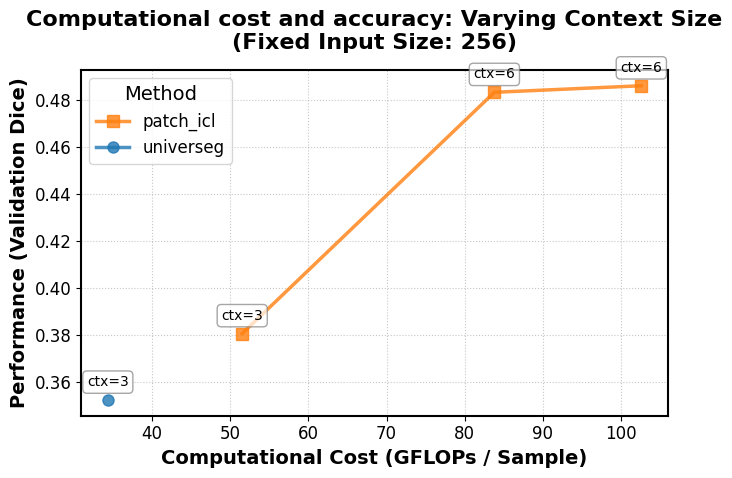

Method: patch_icl, in values:
  in=128, GFLOPs=51.526, Dice=0.3807
  in=256, GFLOPs=112.314, Dice=0.4167
  in=512, GFLOPs=307.543, Dice=0.4018
Method: universeg, in values:
  in=128, GFLOPs=34.335, Dice=0.3524
  in=256, GFLOPs=137.338, Dice=0.3974
  in=512, GFLOPs=549.353, Dice=0.3849


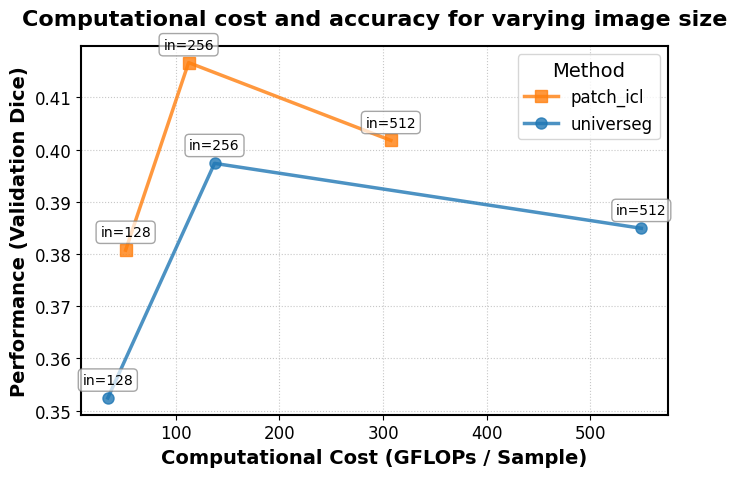

In [7]:
import matplotlib.pyplot as plt

# Set publication-ready style
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.autolayout': True,
    'axes.linewidth': 1.5,
})

# Convert runs_data to DataFrame (using filtered_dice)
df = pd.DataFrame.from_dict(runs_data, orient='index')

# Use filtered_dice for plotting
dice_col = 'filtered_dice'

def plot_pareto(df, vary_col, fixed_col, fixed_val, title, filename, label_prefix):
    fig, ax = plt.subplots(figsize=(7, 5))
    
    # Filter for the specific experiment
    plot_df = df[df[fixed_col] == fixed_val].copy()
    
    # Remove rows with missing data
    plot_df = plot_df.dropna(subset=['gflops_per_sample', dice_col])
    
    if plot_df.empty:
        print(f"No data found for {fixed_col} == {fixed_val}. Skipping plot.")
        return

    methods = plot_df['method'].unique()
    colors = {'universeg': 'tab:blue', 'patch_icl': 'tab:orange'}
    markers = {'universeg': 'o', 'patch_icl': 's'}
    
    # Plot each method as its own line
    for method in methods:
        method_df = plot_df[plot_df['method'] == method].sort_values('gflops_per_sample')
        
        ax.plot(method_df['gflops_per_sample'], method_df[dice_col], 
                marker=markers.get(method, 'o'), color=colors.get(method, 'k'), 
                label=method, markersize=8, linewidth=2.5, alpha=0.8)
        
        # Annotate each data point
        for _, row in method_df.iterrows():
            ax.annotate(f"{label_prefix}={int(row[vary_col])}", 
                        (row['gflops_per_sample'], row[dice_col]),
                        textcoords="offset points", 
                        xytext=(0, 10),
                        ha='center', 
                        fontsize=10,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
        # Print plotted values
        print(f"Method: {method}, {label_prefix} values:")
        for _, row in method_df.iterrows():
            print(f"  {label_prefix}={int(row[vary_col])}, GFLOPs={row['gflops_per_sample']:.3f}, Dice={row[dice_col]:.4f}")

    # Add filter info to title if filtering is active
    filter_info = ""

    
    ax.set_xlabel('Computational Cost (GFLOPs / Sample)', fontweight='bold')
    ax.set_ylabel('Performance (Validation Dice)', fontweight='bold')
    ax.set_title(title + filter_info, pad=15, fontweight='bold')
    ax.legend(title="Method")
    ax.grid(True, linestyle=':', alpha=0.7)
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

# Plot for Varying Context Size (Fixing Input Size to 128)
plot_pareto(df, 
            vary_col='context_size', 
            fixed_col='input_size', 
            fixed_val=128, 
            title='Computational cost and accuracy: Varying Context Size\n(Fixed Input Size: 256)', 
            filename='pareto_context_size.pdf',
            label_prefix='ctx')

# Plot for Varying Input Size (Fixing Context Size to 3)
plot_pareto(df, 
            vary_col='input_size', 
            fixed_col='context_size', 
            fixed_val=3, 
            title='Computational cost and accuracy for varying image size', 
            filename='pareto_input_size.pdf',
            label_prefix='in')